1. Explorarea setului de date


In [3]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Număr de exemple:", X.shape[0])
print("Număr de caracteristici:", X.shape[1])
print("Denumirile caracteristicilor:", iris.feature_names)
print("Numele claselor:", iris.target_names)

Număr de exemple: 150
Număr de caracteristici: 4
Denumirile caracteristicilor: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Numele claselor: ['setosa' 'versicolor' 'virginica']


2. Împărțirea setului în date de antrenament și testare


In [4]:
from sklearn.model_selection import train_test_split

# 2.1
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 2.2
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


3. Preprocesarea datelor


In [5]:
from sklearn.preprocessing import StandardScaler

#3.1
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#3.2
print(" Înainte de scalare ")
print(X_train[:3])

print("\n După scalare ")
print(X_train_scaled[:3])

 Înainte de scalare 
[[4.6 3.6 1.  0.2]
 [5.7 4.4 1.5 0.4]
 [6.7 3.1 4.4 1.4]]

 După scalare 
[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]]


4. Construirea și antrenarea modelului KNN

In [6]:
from sklearn.neighbors import KNeighborsClassifier

# 4.1
knn = KNeighborsClassifier(n_neighbors=3)

# 4.2
knn.fit(X_train_scaled, y_train)

accuracy = knn.score(X_test_scaled, y_test)

print("Acuratețe:", accuracy)

Acuratețe: 1.0


5. Explorarea impactului valorii k

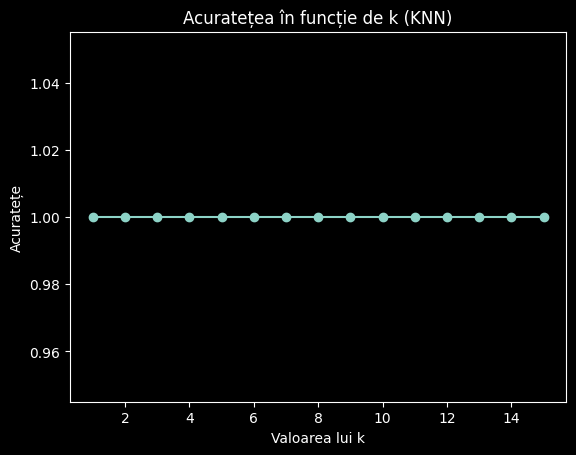

In [9]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# 5.1
k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    acc = knn.score(X_test_scaled, y_test)
    accuracies.append(acc)

# 5.2
plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Valoarea lui k")
plt.ylabel("Acuratețe")
plt.title("Acuratețea în funcție de k (KNN)")
plt.show()

6. Evaluarea modelului


In [10]:
from sklearn.metrics import confusion_matrix, classification_report

# 6.1
y_pred = knn.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
print("Matricea de confuzie:")
print(cm)

# 6.2
print("\nRaport de clasificare:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Matricea de confuzie:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Raport de clasificare:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



7. Vizualizarea datelor

7.1 Scatter plot

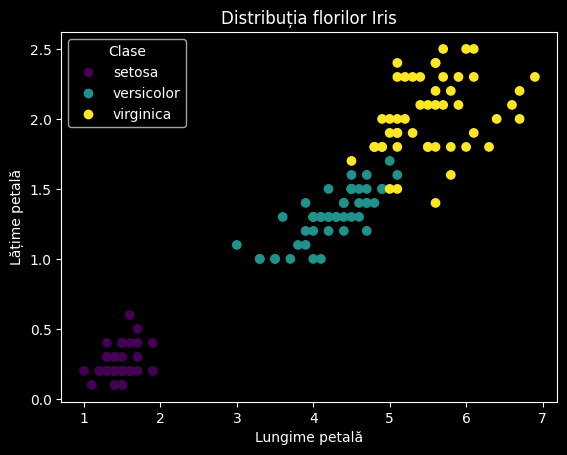

In [11]:
import matplotlib.pyplot as plt

X_plot = X[:, [2, 3]]

plt.figure()

scatter = plt.scatter(
    X_plot[:, 0],
    X_plot[:, 1],
    c=y
)

plt.xlabel("Lungime petală")
plt.ylabel("Lățime petală")
plt.title("Distribuția florilor Iris")

handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names, title="Clase")

plt.show()

7.2 Predicție pentru o floare nouă

In [13]:
lungime_sepala = float(input("Lungime sepala: "))
latime_sepala = float(input("Latime sepala: "))
lungime_petala = float(input("Lungime petala: "))
latime_petala = float(input("Latime petala: "))

floare_noua = [[lungime_sepala, latime_sepala, lungime_petala, latime_petala]]

floare_noua_scaled = scaler.transform(floare_noua)

predictie = knn.predict(floare_noua_scaled)

print("Specia prezisă: ", iris.target_names[predictie][0])

Specia prezisă:  virginica
